In [1]:
import pandas as pd
import numpy as np


np.random.seed(42)

# Number of houses
n = 1000

# Generate house features
area_sqft = np.random.randint(500, 4001, n)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 5, n)
age_years = np.random.randint(0, 41, n)

location = np.random.choice(
    ["Urban", "Suburban", "Rural"],
    n,
    p=[0.45, 0.35, 0.20]
)

parking = np.random.choice(
    ["Yes", "No"],
    n,
    p=[0.70, 0.30]
)

furnished = np.random.choice(
    ["Furnished", "Semi-Furnished", "Unfurnished"],
    n,
    p=[0.35, 0.40, 0.25]
)

# Location effect on price
location_effect = np.select(
    [
        location == "Urban",
        location == "Suburban",
        location == "Rural"
    ],
    [
        1500000,
        800000,
        300000
    ]
)

# Parking effect
parking_effect = np.where(parking == "Yes", 300000, 0)

# Furnished effect
furnished_effect = np.select(
    [
        furnished == "Furnished",
        furnished == "Semi-Furnished",
        furnished == "Unfurnished"
    ],
    [
        500000,
        250000,
        0
    ]
)

# Generate realistic house price
price = (
    area_sqft * 8500
    + bedrooms * 500000
    + bathrooms * 350000
    - age_years * 75000
    + location_effect
    + parking_effect
    + furnished_effect
    + np.random.normal(0, 500000, n)
)

# Make sure prices remain positive
price = np.maximum(price, 1000000)

# Create DataFrame
df = pd.DataFrame({
    "Area_sqft": area_sqft,
    "Bedrooms": bedrooms,
    "Bathrooms": bathrooms,
    "Age_years": age_years,
    "Location": location,
    "Parking": parking,
    "Furnished": furnished,
    "Price": price.round(0)
})

# Display first 5 rows
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Location,Parking,Furnished,Price
0,3674,2,1,22,Suburban,No,Furnished,31582674.0
1,1360,1,2,23,Suburban,Yes,Semi-Furnished,11794210.0
2,1794,2,1,12,Suburban,Yes,Unfurnished,15980613.0
3,1630,1,1,21,Suburban,Yes,Unfurnished,14701001.0
4,1595,4,2,36,Urban,No,Unfurnished,15591208.0


In [2]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (1000, 8)

Columns:
['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Location', 'Parking', 'Furnished', 'Price']


In [3]:
df.to_csv("house_prices.csv", index=False)

print("Dataset saved successfully as house_prices.csv")

Dataset saved successfully as house_prices.csv


In [4]:
import pandas as pd

df = pd.read_csv("house_prices.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 8


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area_sqft  1000 non-null   int64  
 1   Bedrooms   1000 non-null   int64  
 2   Bathrooms  1000 non-null   int64  
 3   Age_years  1000 non-null   int64  
 4   Location   1000 non-null   object 
 5   Parking    1000 non-null   object 
 6   Furnished  1000 non-null   object 
 7   Price      1000 non-null   float64
dtypes: float64(1), int64(4), object(3)
memory usage: 62.6+ KB


In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Area_sqft    0
Bedrooms     0
Bathrooms    0
Age_years    0
Location     0
Parking      0
Furnished    0
Price        0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2303.765000,2.979000,2.467000,20.384000,2.190185e+07
std,1020.993533,1.414411,1.134989,11.792863,8.854863e+06
min,501.000000,1.000000,1.000000,0.000000,4.250659e+06
25%,1428.000000,2.000000,1.000000,10.000000,1.453671e+07
50%,2258.500000,3.000000,2.000000,20.000000,2.134341e+07
75%,3274.750000,4.000000,4.000000,31.000000,2.997372e+07
max,3999.000000,5.000000,4.000000,40.000000,3.915102e+07


In [10]:
print("Location:", df["Location"].unique())
print("Parking:", df["Parking"].unique())
print("Furnished:", df["Furnished"].unique())

Location: ['Suburban' 'Urban' 'Rural']
Parking: ['No' 'Yes']
Furnished: ['Furnished' 'Semi-Furnished' 'Unfurnished']


In [11]:
print("Location distribution:")
print(df["Location"].value_counts())

print("\nParking distribution:")
print(df["Parking"].value_counts())

print("\nFurnished distribution:")
print(df["Furnished"].value_counts())

Location distribution:
Location
Urban       412
Suburban    384
Rural       204
Name: count, dtype: int64

Parking distribution:
Parking
Yes    724
No     276
Name: count, dtype: int64

Furnished distribution:
Furnished
Semi-Furnished    405
Furnished         355
Unfurnished       240
Name: count, dtype: int64


In [12]:
correlation = df.select_dtypes(
    include="number"
).corr()

correlation

,Area_sqft,Bedrooms,Bathrooms,Age_years,Price
Area_sqft,1.000000,0.060843,-0.028515,-0.041846,0.987157
Bedrooms,0.060843,1.000000,0.028563,-0.045485,0.143086
Bathrooms,-0.028515,0.028563,1.000000,0.044997,0.014949
Age_years,-0.041846,-0.045485,0.044997,1.000000,-0.143186
Price,0.987157,0.143086,0.014949,-0.143186,1.000000


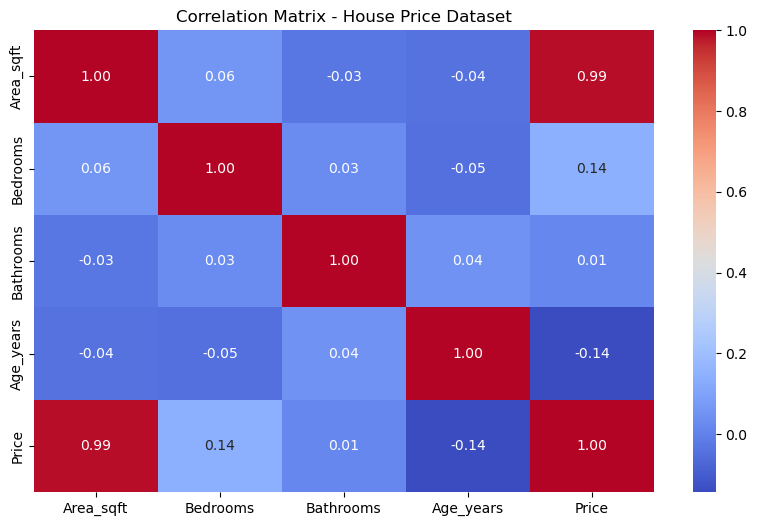

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - House Price Dataset")
plt.show()

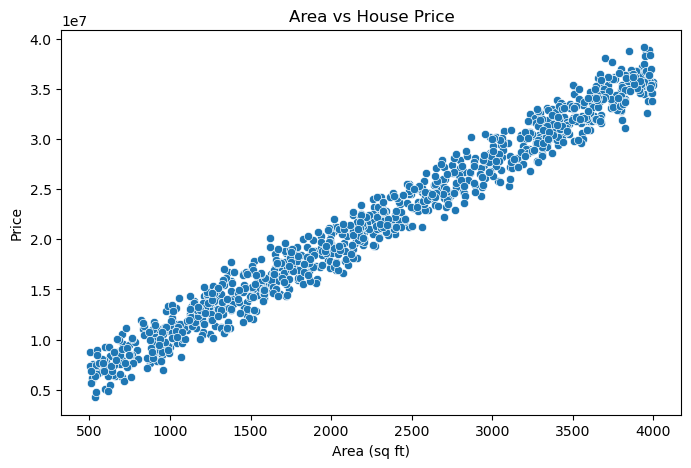

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Area_sqft",
    y="Price"
)

plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.show()

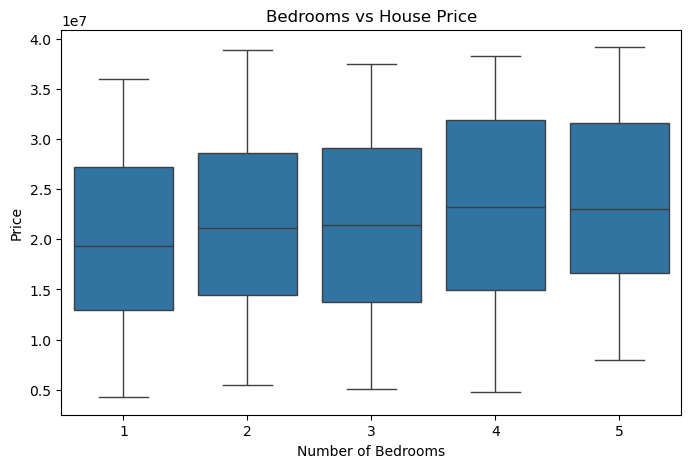

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Bedrooms",
    y="Price"
)

plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.show()

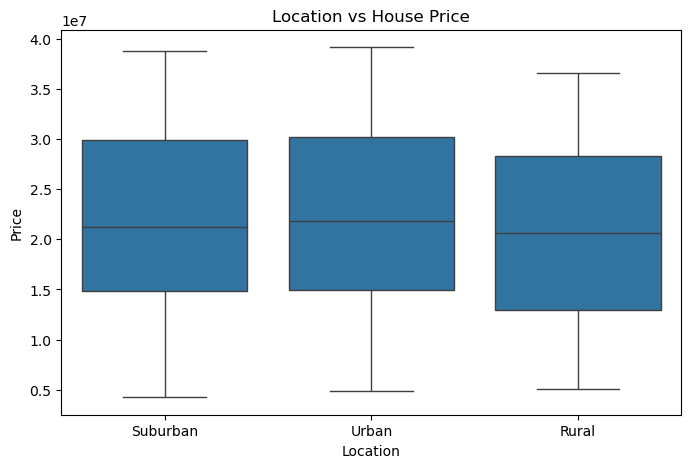

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Location",
    y="Price"
)

plt.title("Location vs House Price")
plt.xlabel("Location")
plt.ylabel("Price")
plt.show()

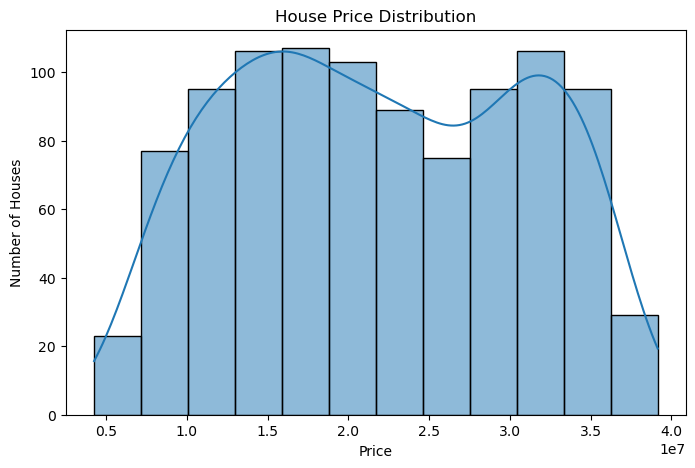

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Price",
    kde=True
)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

In [18]:
X = df.drop("Price", axis=1)
y = df["Price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 7)
Target shape: (1000,)


In [19]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "Location",
        "Parking",
        "Furnished"
    ],
    drop_first=True
)

print("Encoded feature shape:", X_encoded.shape)
print("\nEncoded columns:")
print(X_encoded.columns.tolist())

Encoded feature shape: (1000, 9)

Encoded columns:
['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Location_Suburban', 'Location_Urban', 'Parking_Yes', 'Furnished_Semi-Furnished', 'Furnished_Unfurnished']


In [20]:
X_encoded.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Location_Suburban,Location_Urban,Parking_Yes,Furnished_Semi-Furnished,Furnished_Unfurnished
0,3674,2,1,22,True,False,False,False,False
1,1360,1,2,23,True,False,True,True,False
2,1794,2,1,12,True,False,True,False,True
3,1630,1,1,21,True,False,True,False,True
4,1595,4,2,36,False,True,False,False,True


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (800, 9)
Testing features : (200, 9)
Training target  : (800,)
Testing target   : (200,)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [23]:

from sklearn.linear_model import LinearRegression

print("Linear Regression imported successfully.")

Linear Regression imported successfully.


In [24]:
linear_model = LinearRegression()

print("Linear Regression model created successfully.")

Linear Regression model created successfully.


In [25]:
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [26]:
y_pred_linear = linear_model.predict(X_test_scaled)

print("Predictions created successfully.")
print("Number of predictions:", len(y_pred_linear))

Predictions created successfully.
Number of predictions: 200


In [27]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_linear
})

comparison.head(10)

,Actual Price,Predicted Price
0,31993505.0,3.262279e+07
1,32021835.0,3.146295e+07
2,30895669.0,3.139149e+07
3,31959122.0,3.228798e+07
4,18231023.0,1.876642e+07
5,37497748.0,3.735629e+07
6,17803637.0,1.809758e+07
7,15540258.0,1.587403e+07
8,13180939.0,1.340756e+07
9,24637584.0,2.446319e+07


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("------------------------")
print("MAE  :", round(mae_linear, 2))
print("RMSE :", round(rmse_linear, 2))
print("R²   :", round(r2_linear, 4))

Linear Regression Results
------------------------
MAE  : 419056.57
RMSE : 512729.34
R²   : 0.9967


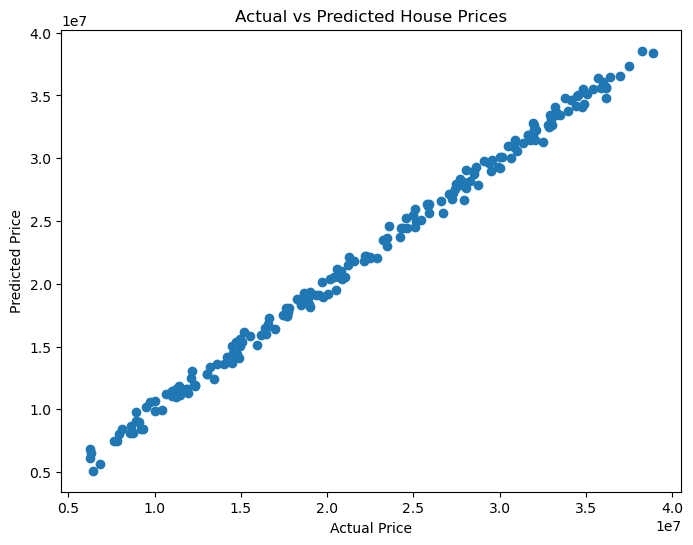

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [30]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest Regressor imported successfully.")

Random Forest Regressor imported successfully.


In [31]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

print("Random Forest Regressor created successfully.")

Random Forest Regressor created successfully.


In [32]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


In [33]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions created successfully.")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions created successfully.
Number of predictions: 200


In [34]:
rf_comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_rf
})

rf_comparison.head(10)

,Actual Price,Predicted Price
0,31993505.0,3.211841e+07
1,32021835.0,3.213947e+07
2,30895669.0,3.196341e+07
3,31959122.0,3.241005e+07
4,18231023.0,1.837172e+07
5,37497748.0,3.659524e+07
6,17803637.0,1.826669e+07
7,15540258.0,1.552779e+07
8,13180939.0,1.355362e+07
9,24637584.0,2.459069e+07


In [35]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("MAE  :", round(mae_rf, 2))
print("RMSE :", round(rmse_rf, 2))
print("R²   :", round(r2_rf, 4))

Random Forest Results
--------------------
MAE  : 680709.2
RMSE : 850016.71
R²   : 0.991


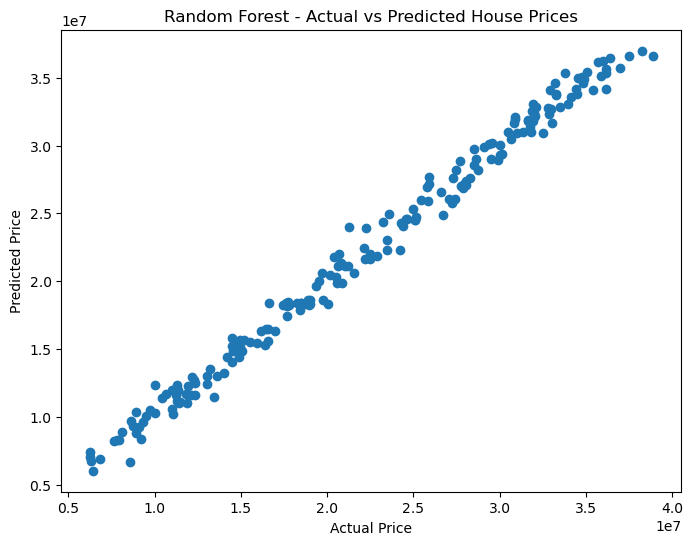

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest - Actual vs Predicted House Prices")

plt.show()

In [37]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2 Score": [
        r2_linear,
        r2_rf
    ]
})

model_comparison.round(2)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,419056.57,512729.34,1.00
1,Random Forest,680709.20,850016.71,0.99


In [38]:
print(model_comparison.round(2))

               Model        MAE       RMSE  R2 Score
0  Linear Regression  419056.57  512729.34      1.00
1      Random Forest  680709.20  850016.71      0.99


In [39]:
best_model_name = model_comparison.loc[
    model_comparison["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [40]:
if best_model_name == "Linear Regression":
    final_model = linear_model

elif best_model_name == "Random Forest":
    final_model = random_forest_model

print("Final model selected:", best_model_name)

Final model selected: Linear Regression


In [41]:
import joblib

joblib.dump(
    final_model,
    "house_price_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [42]:
joblib.dump(
    list(X_encoded.columns),
    "house_price_features.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!


In [44]:
joblib.dump(
    scaler,
    "house_price_scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [46]:
import os



print(
    "Model:",
    os.path.exists("house_price_model.pkl")
)

print(
    "Features:",
    os.path.exists("house_price_features.pkl")
)

print(
    "Scaler:",
    os.path.exists("house_price_scaler.pkl")
)

Model: True
Features: True
Scaler: True
